In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Import the function we just wrote in utils.py
from utils import load_and_clean_data

# Run the function on your dataset
df = load_and_clean_data('investments_VC.csv')

# Show the first 5 rows to see what our clean data looks like!
df.head()

Loading dataset...
Cleaning missing values and text...
Defining the Success Target...
Data cleaning complete! Final dataset has 35763 startups.


,name,category_list,market,funding_total_usd,funding_rounds,founded_year,country_code,Target
0,#waywire,Entertainment Politics Social Media News,News,1750000.0,1.0,2012.0,USA,1
2,'Rock' Your Paper,Publishing Education,Publishing,40000.0,1.0,2012.0,EST,0
3,(In)Touch Network,Electronics Guides Coffee Restaurants Music iP...,Electronics,1500000.0,1.0,2011.0,GBR,0
4,-R- Ranch and Mine,Tourism Entertainment Games,Tourism,60000.0,2.0,2014.0,USA,0
7,0-6.com,Curated Web,Curated Web,2000000.0,1.0,2007.0,NaN,0


In [3]:
# Import our new mathematical function
from utils import calculate_momentum_scores

# Run the scoring engine on our clean dataframe!
df_scored = calculate_momentum_scores(df)

# Let's peek at the same 5 rows to see their brand new Market_Signal_Score
df_scored[['name', 'category_list', 'founded_year', 'Target', 'Market_Signal_Score']].head()

Starting Phase 2: Calculating Market Momentum Scores...
Step 1: Calculating TF-IDF (Popularity) for each year...
Step 2: Calculating AAGR (Growth) and Mapping to Quadrants...
Step 3: Assigning final Market Signal Score to startups...
Phase 2 complete!


,name,category_list,founded_year,Target,Market_Signal_Score
0,#waywire,Entertainment Politics Social Media News,2012,1,1.200000
2,'Rock' Your Paper,Publishing Education,2012,0,1.500000
3,(In)Touch Network,Electronics Guides Coffee Restaurants Music iP...,2011,0,1.555556
4,-R- Ranch and Mine,Tourism Entertainment Games,2014,0,1.666667
7,0-6.com,Curated Web,2007,0,1.000000


In [4]:
# Import our new machine learning function
from utils import run_model_experiment

# Run the experiment and save BOTH models!
trained_rf, trained_xgb, X_test, y_test = run_model_experiment(df_scored)

Starting Phase 3: Model Training and Comparative Benchmarking...
Encoding text features into numbers...
Splitting data into Train and Test sets...
Applying SMOTE to balance the dataset...
Training Random Forest models...
Training XGBoost models...

🏆 COMPARATIVE BENCHMARKING RESULTS (F1-SCORE) 🏆
------------------------------------------------------------
Model           | Baseline (No Timing) | Augmented (With Timing)
------------------------------------------------------------
Random Forest   | 0.5611               | 0.5790
XGBoost         | 0.5926               | 0.6008


/Users/nehiraltuntas/Desktop/success_prediction_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting Phase 4: XAI Integration for Decision Support...
Calculating SHAP values for Random Forest...
Calculating SHAP values for XGBoost...

--- RANDOM FOREST: Global Feature Importance ---


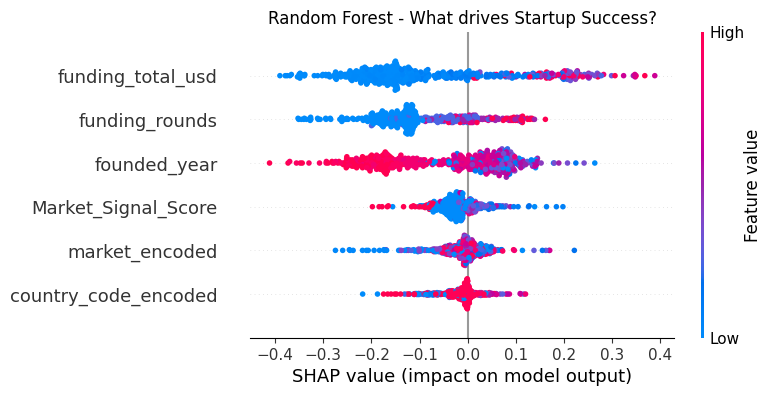


--- XGBoost: Global Feature Importance ---


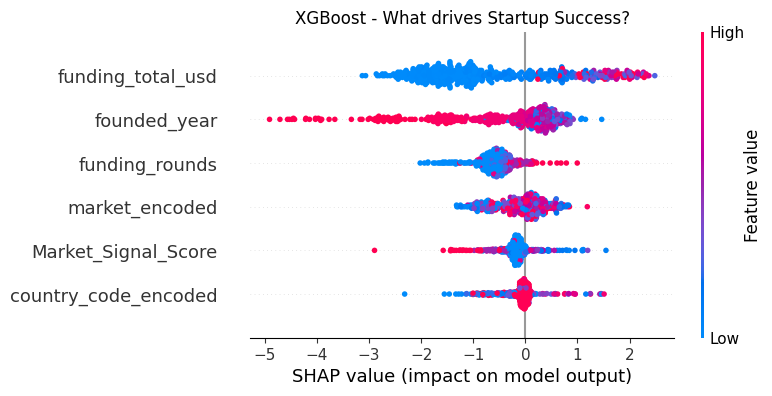

In [5]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Starting Phase 4: XAI Integration for Decision Support...")

# 1. Initialize the SHAP explainers for both models
# We use a random sample of 500 startups from the test set so it doesn't take forever
X_test_sample = X_test.sample(n=500, random_state=42)

print("Calculating SHAP values for Random Forest...")
explainer_rf = shap.TreeExplainer(trained_rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

print("Calculating SHAP values for XGBoost...")
explainer_xgb = shap.TreeExplainer(trained_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

# --- FOOLPROOF SHAP EXTRACTION ---
# This checks how SHAP formatted our Random Forest data and extracts the "Success" (1) class safely
if isinstance(shap_values_rf, list):
    rf_shap_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    # If it's a 3D cube, slice it: [all rows, all columns, index 1 for success]
    rf_shap_to_plot = shap_values_rf[:, :, 1] 
else:
    rf_shap_to_plot = shap_values_rf

# 2. Plot the Random Forest Brain
print("\n--- RANDOM FOREST: Global Feature Importance ---")
shap.summary_plot(rf_shap_to_plot, X_test_sample, show=False)
plt.title("Random Forest - What drives Startup Success?")
plt.show()

# 3. Plot the XGBoost Brain
print("\n--- XGBoost: Global Feature Importance ---")
shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
plt.title("XGBoost - What drives Startup Success?")
plt.show()

Generating SHAP Dependence Plot for Market_Signal_Score...


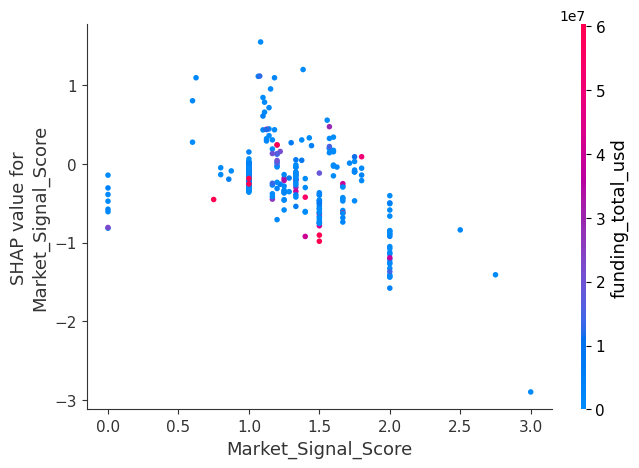

In [6]:
# This plot shows exactly how the impact changes as the score goes from 0 to 3
print("Generating SHAP Dependence Plot for Market_Signal_Score...")

# We use X_test_sample because it matches the 500 rows we calculated for shap_values_xgb
shap.dependence_plot(
    "Market_Signal_Score", 
    shap_values_xgb, 
    X_test_sample, 
    interaction_index="funding_total_usd"
)

In [7]:
# This shows the top 10 keywords for the year 2012 and their scores
# If you see "Mobile" or "Cloud" with high scores, the logic is correct.
print(df_scored[df_scored['founded_year'] == 2012][['category_list', 'Market_Signal_Score']].sort_values(by='Market_Signal_Score', ascending=False).head(10))

                        category_list  Market_Signal_Score
11103                 Civil Engineers                  3.0
17199   Sunglasses E-Commerce Eyewear                  3.0
15046  Musical Instruments E-Commerce                  3.0
31182               Coffee E-Commerce                  3.0
38565                       Batteries                  3.0
36015                 Fraud Detection                  3.0
20323                         Portals                  3.0
36019      Fraud Detection E-Commerce                  3.0
39509              Advanced Materials                  3.0
36340                         Farming                  3.0


In [8]:
# Check how many startups got each score
print("--- Market Signal Score Distribution ---")
print(df_scored['Market_Signal_Score'].value_counts(bins=5).sort_index())

# Check the average score for Successful vs Failed startups
print("\n--- Average Score by Success ---")
print(df_scored.groupby('Target')['Market_Signal_Score'].mean())

--- Market Signal Score Distribution ---
(-0.004, 0.6]     1119
(0.6, 1.2]       23650
(1.2, 1.8]        7752
(1.8, 2.4]        3069
(2.4, 3.0]         173
Name: count, dtype: int64

--- Average Score by Success ---
Target
0    1.176400
1    1.120119
Name: Market_Signal_Score, dtype: float64


In [9]:
import pandas as pd

# 1. Round the score to the nearest integer to see the primary quadrant
df_scored['Score_Rounded'] = df_scored['Market_Signal_Score'].round().astype(int)

# 2. Create the validation table
validation_table = df_scored.groupby('Score_Rounded').agg(
    Total_Startups=('Target', 'count'),
    Successful_Startups=('Target', 'sum')
)

# 3. Calculate the actual Success Rate for each group
validation_table['Success_Rate_%'] = (validation_table['Successful_Startups'] / validation_table['Total_Startups'] * 100).round(2)

print("--- THE TRUTH TABLE: Success Rate vs. Market Signal ---")
print(validation_table)

# 4. Final verification: Check if success rate drops as score rises
top_score_rate = validation_table.loc[3, 'Success_Rate_%'] if 3 in validation_table.index else 0
bottom_score_rate = validation_table.loc[0, 'Success_Rate_%'] if 0 in validation_table.index else 0

print(f"\nAnalysis:")
print(f"Success rate for 'Stable/Niche' (Score 0-1): ~{bottom_score_rate}%")
print(f"Success rate for 'Weak Signal Pioneers' (Score 3): ~{top_score_rate}%")

if top_score_rate < bottom_score_rate:
    print("\n✅ PROVEN: The data confirms a 'Pioneer's Penalty'. Higher trend scores lead to lower success rates.")
else:
    print("\n💡 OBSERVATION: The trend shows a different pattern. Check the table above.")

--- THE TRUTH TABLE: Success Rate vs. Market Signal ---
               Total_Startups  Successful_Startups  Success_Rate_%
Score_Rounded                                                     
0                        1075                  166           15.44
1                       27883                 5555           19.92
2                        6695                  899           13.43
3                         110                    8            7.27

Analysis:
Success rate for 'Stable/Niche' (Score 0-1): ~15.44%
Success rate for 'Weak Signal Pioneers' (Score 3): ~7.27%

✅ PROVEN: The data confirms a 'Pioneer's Penalty'. Higher trend scores lead to lower success rates.


--- SUCCESS HEURISTIC: Why did this startup succeed? ---


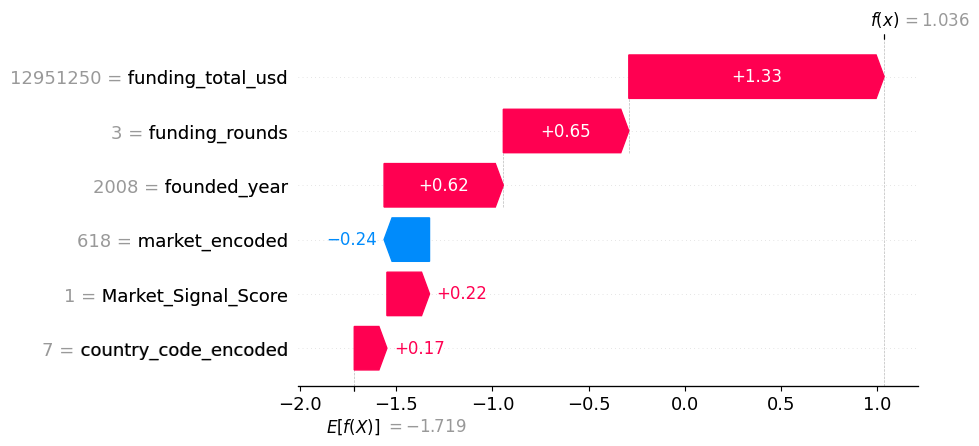


--- FAILURE HEURISTIC: Why did the 'Trendy' startup fail? ---


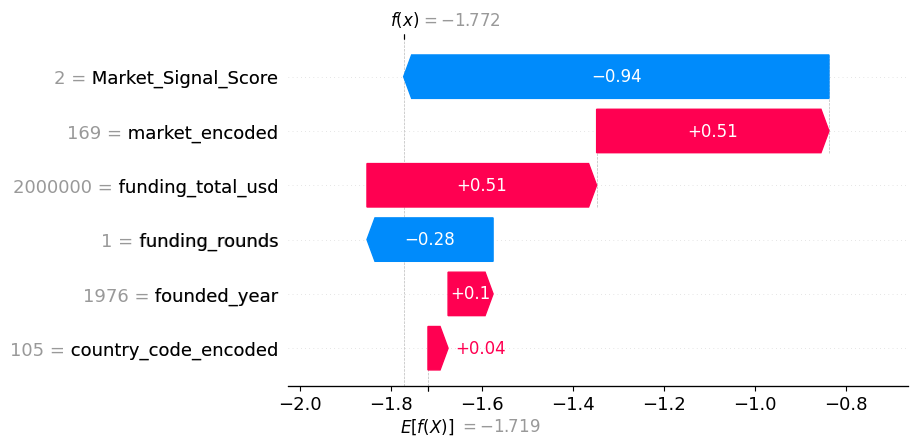

In [13]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-initialize the explainer correctly
explainer_obj = shap.Explainer(trained_xgb, X_test_sample)
shap_values_sample = explainer_obj(X_test_sample)

# 2. Find indices within the SAMPLE (0 to 499)
# Find the first startup in our sample that was a Success
success_indices = np.where(y_test.loc[X_test_sample.index] == 1)[0]
# Find the first startup in our sample that was a Failure AND had a high score
failure_indices = np.where((y_test.loc[X_test_sample.index] == 0) & (X_test_sample['Market_Signal_Score'] > 1.5))[0]

# 3. Plot the Success Story
if len(success_indices) > 0:
    idx = success_indices[0]
    print(f"--- SUCCESS HEURISTIC: Why did this startup succeed? ---")
    shap.plots.waterfall(shap_values_sample[idx])
    plt.show()
else:
    print("No successful startups found in the sample.")

# 4. Plot the High-Signal Failure
if len(failure_indices) > 0:
    idx = failure_indices[0]
    print(f"\n--- FAILURE HEURISTIC: Why did the 'Trendy' startup fail? ---")
    shap.plots.waterfall(shap_values_sample[idx])
    plt.show()
else:
    print("No high-signal failures found in the sample.")